#Project Title: Credit Scoring Model
Internship Domain: Machine Learning

Company: CodeAlpha

Project Goal: Predict an individual's creditworthiness and default risk using historical financial, personal, and loan data.

#2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools for preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Plotting config
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

#3. Load Dataset

In [3]:
from google.colab import files
import os

if not os.path.exists('credit_risk_dataset.csv'):
    print("Please upload credit_risk_dataset.csv using the upload button below:")
    uploaded = files.upload()

df = pd.read_csv('credit_risk_dataset.csv')

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Count ---")
print(f"Duplicates: {df.duplicated().sum()}")

Please upload credit_risk_dataset.csv using the upload button below:


Saving credit_risk_dataset.csv to credit_risk_dataset.csv
--- First 5 Rows ---


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



--- Dataset Shape ---
Rows: 32581, Columns: 12

--- Column Names & Data Types ---
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

--- Missing Values Count ---
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length      

#4. Data Cleaning

In [4]:
initial_shape = df.shape
print(f"Initial Shape: {initial_shape}")

# 1. Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# 2. Filter obvious data entry errors/outliers
# Age over 100 or employment length over 60 years are likely errors in this dataset
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

final_shape = df.shape
print(f"Cleaned Shape: {final_shape}")
print(f"Removed {initial_shape[0] - final_shape[0]} invalid/duplicate rows.")

Initial Shape: (32581, 12)
Cleaned Shape: (31522, 12)
Removed 1059 invalid/duplicate rows.


#5. Exploratory Data Analysis (EDA)

/tmp/ipykernel_809/1019256381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_status', palette='Set2')


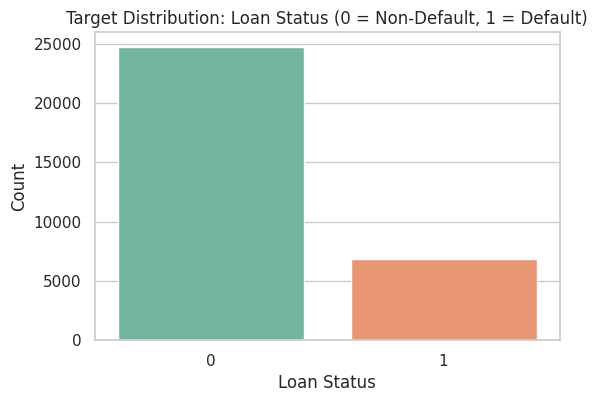

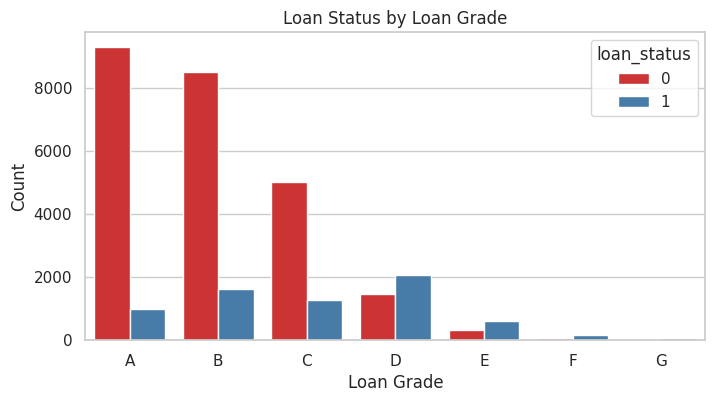

/tmp/ipykernel_809/1019256381.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='person_income', palette='Set2')


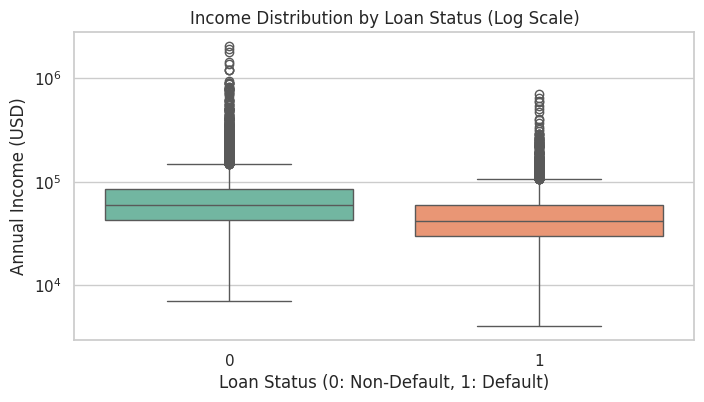

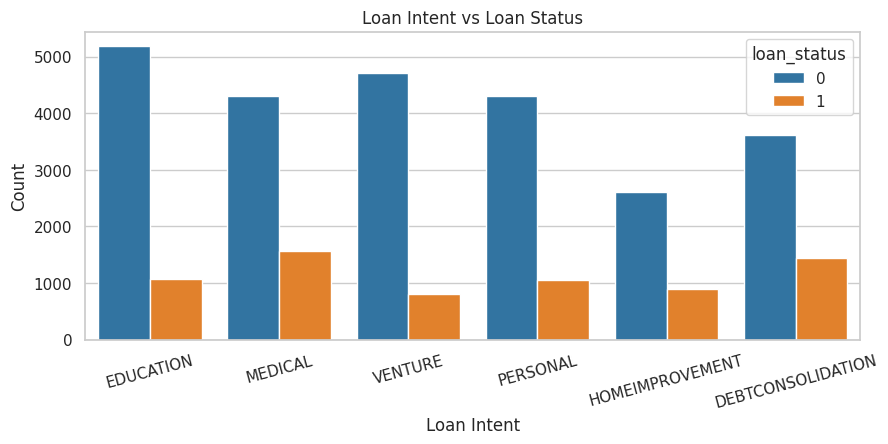

In [6]:

# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette='Set2')
plt.title("Target Distribution: Loan Status (0 = Non-Default, 1 = Default)")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# Loan Status vs Loan Grade
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='loan_grade', hue='loan_status', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'], palette='Set1')
plt.title("Loan Status by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.show()

# Income vs Loan Status
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='loan_status', y='person_income', palette='Set2')
plt.yscale('log') # Log scale for income clarity
plt.title("Income Distribution by Loan Status (Log Scale)")
plt.xlabel("Loan Status (0: Non-Default, 1: Default)")
plt.ylabel("Annual Income (USD)")
plt.show()

# Loan Intent vs Loan Status
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='loan_intent', hue='loan_status', palette='tab10')
plt.title("Loan Intent vs Loan Status")
plt.xlabel("Loan Intent")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

#6. Feature Engineering

In [7]:

# Feature 1: Income-to-Loan Ratio
df['income_to_loan_ratio'] = df['person_income'] / (df['loan_amnt'] + 1)

# Feature 2: Credit History to Age Ratio
df['cred_hist_age_ratio'] = df['cb_person_cred_hist_length'] / df['person_age']

print("Engineered features created successfully. Sample view:")
display(df[['person_income', 'loan_amnt', 'income_to_loan_ratio', 'cred_hist_age_ratio']].head())

Engineered features created successfully. Sample view:


,person_income,loan_amnt,income_to_loan_ratio,cred_hist_age_ratio
1,9600,1000,9.590410,0.095238
2,9600,5500,1.745137,0.120000
3,65500,35000,1.871375,0.086957
4,54400,35000,1.554241,0.166667
5,9900,2500,3.958417,0.095238


#7. Data Preprocessing & Column Transformers

In [8]:

X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

#8. Train-Test Split

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Target balance in train: {np.bincount(y_train)}")
print(f"Target balance in test:  {np.bincount(y_test)}")

Training set size: 25217 samples
Test set size: 6305 samples
Target balance in train: [19772  5445]
Target balance in test:  [4943 1362]


#9. Model

In [11]:

log_reg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipe.fit(X_train, y_train)
y_pred_lr = log_reg_pipe.predict(X_test)
y_proba_lr = log_reg_pipe.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4943
           1       0.77      0.56      0.65      1362

    accuracy                           0.87      6305
   macro avg       0.83      0.76      0.78      6305
weighted avg       0.86      0.87      0.86      6305



In [12]:

dt_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=6, random_state=42))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]

print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      4943
           1       0.96      0.68      0.79      1362

    accuracy                           0.92      6305
   macro avg       0.94      0.84      0.87      6305
weighted avg       0.93      0.92      0.92      6305



In [13]:

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      4943
           1       0.98      0.72      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



#10. Confusion Matrix Analysis

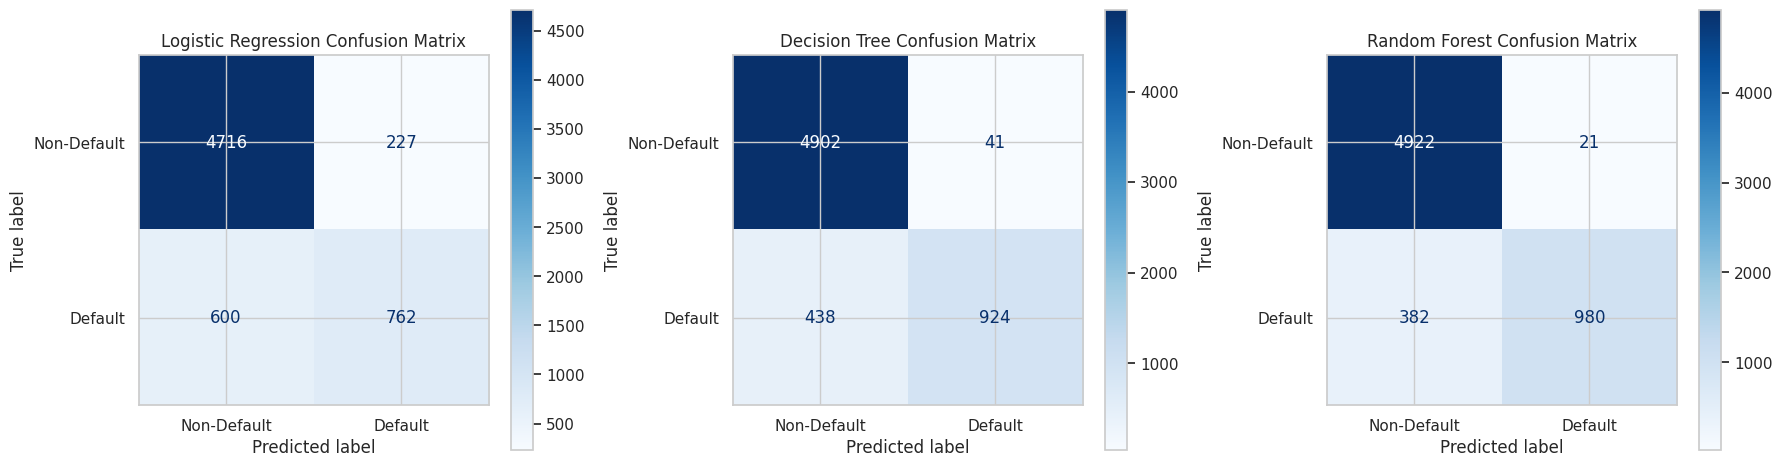

In [14]:
# [Code Cell 11]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [('Logistic Regression', y_pred_lr),
          ('Decision Tree', y_pred_dt),
          ('Random Forest', y_pred_rf)]

for idx, (name, preds) in enumerate(models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

#11. ROC Curve Comparison

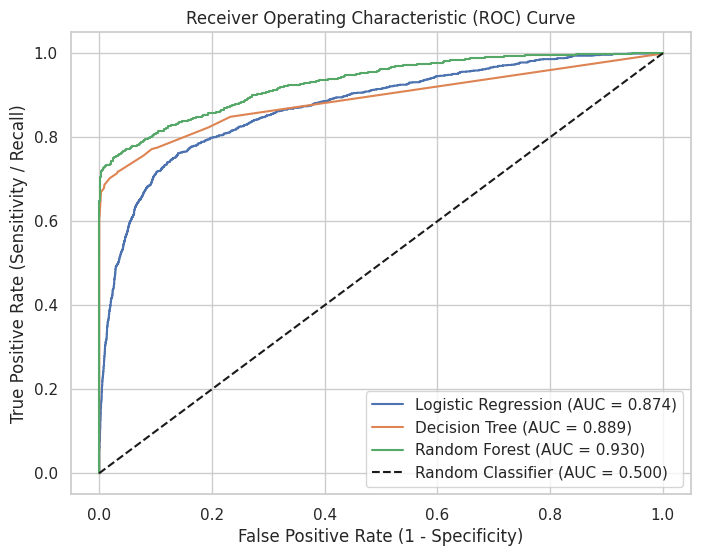

In [15]:

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_dt = roc_auc_score(y_test, y_proba_dt)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right')
plt.show()

# 12 Model Comparison

In [16]:

def get_metrics(model_name, y_true, y_pred, y_proba):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

results = [
    get_metrics('Logistic Regression', y_test, y_pred_lr, y_proba_lr),
    get_metrics('Decision Tree', y_test, y_pred_dt, y_proba_dt),
    get_metrics('Random Forest', y_test, y_pred_rf, y_proba_rf)
]

comparison_df = pd.DataFrame(results).round(4)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8688,0.7705,0.5595,0.6482,0.8742
1,Decision Tree,0.9240,0.9575,0.6784,0.7942,0.8892
2,Random Forest,0.9361,0.9790,0.7195,0.8295,0.9305


#13. Feature Importance

/tmp/ipykernel_809/844630127.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Feature', palette='viridis')


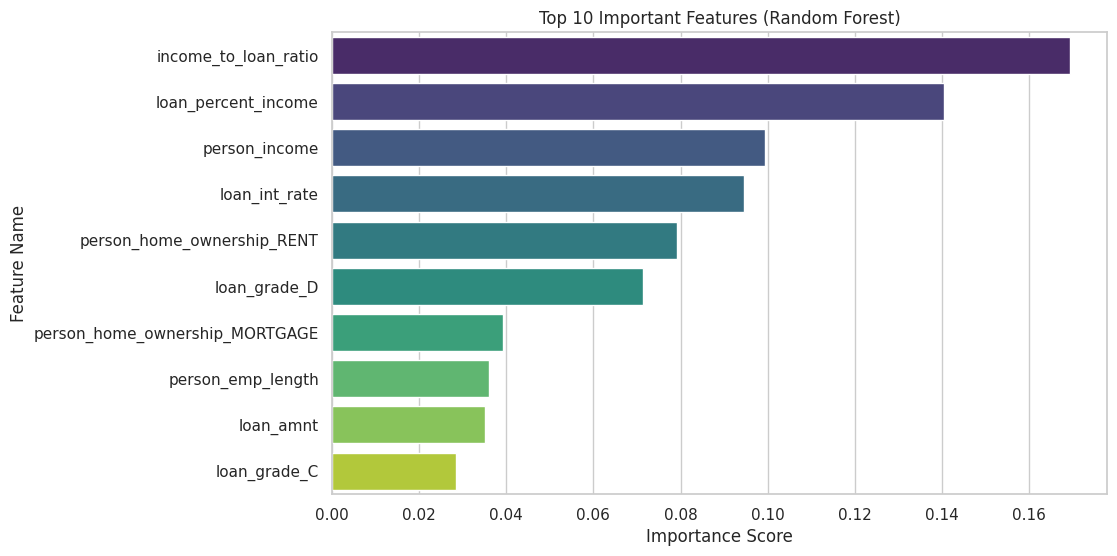

In [17]:

# Retrieve feature names from OneHotEncoder transformer
ohe_feature_names = rf_pipe.named_steps['preprocessor'] \
                           .named_transformers_['cat'] \
                           .named_steps['onehot'] \
                           .get_feature_names_out(cat_cols)

all_feature_names = num_cols + list(ohe_feature_names)

importances = rf_pipe.named_steps['classifier'].feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

#13. Error Analysis

In [18]:

test_analysis = X_test.copy()
test_analysis['Actual'] = y_test
test_analysis['Predicted'] = y_pred_rf

# False Positives: Actual Non-Default (0), Predicted Default (1)
false_positives = test_analysis[(test_analysis['Actual'] == 0) & (test_analysis['Predicted'] == 1)]

# False Negatives: Actual Default (1), Predicted Non-Default (0)
false_negatives = test_analysis[(test_analysis['Actual'] == 1) & (test_analysis['Predicted'] == 0)]

print("--- Sample False Negatives (High Risk Missed by Model) ---")
display(false_negatives[['person_age', 'person_income', 'loan_intent', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']].head())

print("\n--- Sample False Positives (Safe Borrowers Denied) ---")
display(false_positives[['person_age', 'person_income', 'loan_intent', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']].head())

--- Sample False Negatives (High Risk Missed by Model) ---


,person_age,person_income,loan_intent,loan_amnt,loan_int_rate,loan_percent_income
17326,22,44004,EDUCATION,9000,14.11,0.20
8642,23,53950,EDUCATION,15000,16.63,0.28
5615,23,39325,EDUCATION,2800,12.87,0.07
23837,35,62000,HOMEIMPROVEMENT,13000,9.25,0.21
4305,23,52000,PERSONAL,4600,14.96,0.09



--- Sample False Positives (Safe Borrowers Denied) ---


,person_age,person_income,loan_intent,loan_amnt,loan_int_rate,loan_percent_income
23898,28,35000,MEDICAL,10000,14.61,0.29
19017,30,31200,MEDICAL,2400,16.49,0.08
20613,32,37992,VENTURE,5000,16.35,0.13
20654,29,42000,MEDICAL,5000,15.99,0.12
26544,33,42000,MEDICAL,2000,NaN,0.05
